
<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Analisis de Sentimientos en Tweets Laboratorio 5.9}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Giovanni Alejandri Espinosa \\[6pt]
\textbf{Fecha de realización:} & 06/05/2026
\end{array}

</center>


## Contexto:
    
    El año 2020 se vio afectado por el impacto a la sociedad mundial sobre una gripe de alto nivel de contagio así como la causa principal de fallecimientos alrededor del Mundo.
    
    México no ha sido exento del raro virus.
    
    Con el presente Proyecto, el objetivo primordial es desarrollar los algoritmos que ayuden a monitorizar el efecto en los comentarios que en la Red Social de Twitter se emiten, y que ayudé a dar una idea del estado de ánimo de la gente.

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn%3AANd9GcQUpnfdhCKN1C3OIbNrDdyjctlRsA9t6386WWD8JkUzt_X7JiuH&usqp=CAU" alt="Alt text that describes the graphic" title="Title text" />

In [ ]:
!pip install pymongo

In [ ]:
# Importacion de librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#Tienes que descargarte las stopwords primero via nltk.download()
import nltk
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.corpus import wordnet as wn
from nltk import word_tokenize
from nltk.data import load
from nltk.stem import SnowballStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from string import punctuation
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
from sklearn import model_selection, naive_bayes, svm

import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
#Librería MongoDb
#from pymongo import MongoClient
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk import pos_tag
from nltk.corpus import stopwords
from string import punctuation
from nltk.stem import WordNetLemmatizer
import seaborn as sns
import time
from datetime import datetime, date, time, timedelta
import calendar

import json
import re
import urllib
import collections

In [ ]:
non_words = list(punctuation)
non_words.extend(['¿', '¡'])
non_words.extend(map(str,range(10)))


## Preparar los datos


In [ ]:
# Importacion del archivo que se nos proporciono agregandole cabeceras que no contiene
names = ['Id', 'tweet', 'polaridad']
dataset = pd.read_csv('train.txt', sep='\t',names=names)

In [ ]:
with open('train.txt', 'r', encoding='utf-8')  as archivo:
    lista = archivo.read().split('\n')
    print(lista)

['818942405281980417\tNo mames este pinche dolor que pedo? ya mejor llévame Diosito.\tN', '818963123646373892\t@leomall2018 Según yo era como aviso, pero ahora sí ya es oficial\tNEU', '818998133694697472\t@benshorts a juzgar por mis comportamientos autodestructivos en las relaciones, aún quiero serlo\tN', '818822556090105857\t#BuenosDias mundo Twittero ya desperté y estoy listo para vivir un dia mas #ExcelenteMartes\tP', '818993011514372098\tNo pude resolver el rompecabezas en Los rios de Alicia y ahora muero de tristeza\tN', '818645278131568640\to sea ... me urge un Dr. @Rocktor101 (escuchó un programa de males digestivos y así)\tN', '819050320177152000\t@natyamezcua hay pues hay que ver que hacemos para vernos, te extraño, no quiero que te alejes\tNEU', '817393151115689985\t@Eudemonologia87 yo igual y ni así. Este año seré tipo marasalvatrucha para ver si así me traen algo.\tN', '818688468687720448\t@shakira no te puedo llevar en mi bicicleta. Me caí y está descompuesta. Happy to wal

In [ ]:
dataset.head()

,Id,tweet,polaridad
0,818942405281980417,No mames este pinche dolor que pedo? ya mejor ...,N
1,818963123646373892,"@leomall2018 Según yo era como aviso, pero aho...",NEU
2,818998133694697472,@benshorts a juzgar por mis comportamientos au...,N
3,818822556090105857,#BuenosDias mundo Twittero ya desperté y estoy...,P
4,818993011514372098,No pude resolver el rompecabezas en Los rios d...,N


In [ ]:
df=pd.DataFrame(dataset)


X = dataset.iloc[:, 1].values
Y = dataset.iloc[:, 2].values

dX=pd.DataFrame(X)
dX.columns = ['tweet']
dX.head(5)




,tweet
0,No mames este pinche dolor que pedo? ya mejor ...
1,"@leomall2018 Según yo era como aviso, pero aho..."
2,@benshorts a juzgar por mis comportamientos au...
3,#BuenosDias mundo Twittero ya desperté y estoy...
4,No pude resolver el rompecabezas en Los rios d...


In [ ]:

dY=pd.DataFrame(Y)
dY.columns = ['polaridad']
dY.head(5)

,polaridad
0,N
1,NEU
2,N
3,P
4,N


In [ ]:
dY['polaridad'].unique()

array(['N', 'NEU', 'P'], dtype=object)

## Tokenización, Normalización en minúsculas, StopWords, Stemming y Vectorización

In [ ]:
df['tweet'] = [entry.lower() for entry in df['tweet']]

In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
from nltk.tokenize import word_tokenize
# Paso - 1c: Tokenización: en este cada entrada en el corpus se dividirá en un conjunto de palabras
# Paso - 1c: Tokenización
df['tweet'] = df['tweet'].apply(lambda x: word_tokenize(x) if isinstance(x, str) else x)

# Paso - 1d: Eliminar stopwords, no numéricas y aplicar lematización
tag_map = defaultdict(lambda : wn.NOUN)
tag_map['J'] = wn.ADJ
tag_map['V'] = wn.VERB
tag_map['R'] = wn.ADV

for index, entry in enumerate(df['tweet']):
    Final_words = []
    word_Lemmatized = WordNetLemmatizer()
    # Etiquetar POS
    for word, tag in pos_tag(entry):
        if word not in stopwords.words('spanish') and word.isalpha():
            word_Final = word_Lemmatized.lemmatize(word, tag_map[tag[0]])
            Final_words.append(word_Final)
    df.loc[index, 'tweet_final'] = str(Final_words)

print(df.loc[index, 'tweet_final'])

['djrossana', 'lindo', 'martes', 'sueños', 'hagan', 'realidad', 'sé', 'misma', 'copy', 'modas', 'ejemplo', 'seguir']


In [ ]:
df.head(5)

,Id,tweet,polaridad,tweet_final
0,818942405281980417,"[no, mames, este, pinche, dolor, que, pedo, ?,...",N,"['mames', 'pinche', 'dolor', 'pedo', 'mejor', ..."
1,818963123646373892,"[@, leomall2018, según, yo, era, como, aviso, ...",NEU,"['según', 'aviso', 'ahora', 'oficial']"
2,818998133694697472,"[@, benshorts, a, juzgar, por, mis, comportami...",N,"['benshorts', 'juzgar', 'comportamientos', 'au..."
3,818822556090105857,"[#, buenosdias, mundo, twittero, ya, desperté,...",P,"['buenosdias', 'mundo', 'twittero', 'desperté'..."
4,818993011514372098,"[no, pude, resolver, el, rompecabezas, en, los...",N,"['pude', 'resolver', 'rompecabezas', 'rio', 'a..."


## Datos de Entrenamiento y Pruebas

In [ ]:
Train_X, Test_X, Train_Y, Test_Y = model_selection.train_test_split(df['tweet_final'],df['polaridad'],test_size=0.3)

In [ ]:
Train_Y.head(5)

,polaridad
869,P
644,NEU
494,N
441,N
916,N


In [ ]:
Encoder = LabelEncoder()
Train_Y = Encoder.fit_transform(Train_Y)
Test_Y = Encoder.fit_transform(Test_Y)

In [ ]:
print(Train_Y)

[2 1 0 0 0 0 0 1 2 0 0 0 2 2 2 1 2 1 0 2 0 0 2 0 1 1 2 1 0 0 0 0 1 2 1 0 0
 2 2 0 0 1 2 0 0 0 1 2 1 0 0 0 0 0 0 0 0 0 1 0 2 0 0 0 0 2 1 0 1 2 2 2 0 0
 2 2 2 1 2 2 0 2 0 0 1 1 1 0 2 0 2 0 2 0 0 0 1 2 0 2 2 0 2 0 0 1 2 0 0 1 0
 2 0 2 0 2 0 1 0 1 0 0 1 0 0 1 1 0 2 2 0 2 1 0 2 2 0 0 2 1 0 2 2 0 0 2 0 2
 1 1 0 2 1 0 0 0 2 2 2 0 2 0 0 2 0 0 1 2 0 0 0 0 1 0 1 2 0 2 0 2 0 0 1 0 2
 0 2 2 0 2 0 1 2 0 1 0 2 0 1 0 2 0 0 1 0 1 0 2 0 0 0 1 2 0 0 0 0 0 2 0 0 2
 2 0 1 2 2 0 0 0 0 0 2 0 0 2 0 0 0 0 0 2 0 2 1 2 2 1 1 0 0 0 2 2 0 1 0 0 0
 0 2 0 2 0 0 0 2 2 2 2 1 2 0 0 0 1 2 2 0 1 0 0 0 1 0 0 0 2 0 0 2 2 2 0 1 0
 1 0 1 0 0 1 0 2 1 1 0 0 2 1 0 0 2 2 0 1 0 0 0 0 2 0 2 0 0 2 0 0 1 0 2 1 0
 0 2 2 2 0 1 0 0 0 1 0 1 2 1 0 2 2 0 0 0 2 0 2 2 0 2 2 0 1 1 0 0 2 1 2 0 1
 0 2 2 1 2 1 0 1 1 2 0 0 0 2 0 1 2 2 0 0 2 0 2 2 1 0 0 0 0 2 1 2 2 2 0 2 2
 0 2 0 2 1 0 2 0 0 1 2 0 0 2 2 0 0 0 2 0 2 0 2 2 2 0 0 2 2 0 2 2 0 0 0 2 0
 0 1 2 1 2 2 0 1 1 2 2 2 0 1 0 0 2 2 0 0 0 1 2 2 2 2 0 0 1 2 0 0 0 2 0 0 0
 0 1 0 2 0 0 0 2 2 2 1 2 

In [ ]:
df.head()

,Id,tweet,polaridad,tweet_final
0,818942405281980417,"[no, mames, este, pinche, dolor, que, pedo, ?,...",N,"['mames', 'pinche', 'dolor', 'pedo', 'mejor', ..."
1,818963123646373892,"[@, leomall2018, según, yo, era, como, aviso, ...",NEU,"['según', 'aviso', 'ahora', 'oficial']"
2,818998133694697472,"[@, benshorts, a, juzgar, por, mis, comportami...",N,"['benshorts', 'juzgar', 'comportamientos', 'au..."
3,818822556090105857,"[#, buenosdias, mundo, twittero, ya, desperté,...",P,"['buenosdias', 'mundo', 'twittero', 'desperté'..."
4,818993011514372098,"[no, pude, resolver, el, rompecabezas, en, los...",N,"['pude', 'resolver', 'rompecabezas', 'rio', 'a..."


In [ ]:
Tfidf_vect = TfidfVectorizer(max_features=5000)
Tfidf_vect.fit(df['tweet_final'])
Train_X_Tfidf = Tfidf_vect.transform(Train_X)
Test_X_Tfidf = Tfidf_vect.transform(Test_X)

## Identificación de Polaridad con  Algoritmos de Aprendizaje Supervisado

In [ ]:
# Clasificador - Algoritmo - Naive Bayes
# Se ajusta el conjunto de datos de entrenamiento en el clasificador
Naive = naive_bayes.MultinomialNB()
Naive.fit(Train_X_Tfidf,Train_Y)
# Predecir las etiquetas en el conjunto de datos de validación
predictions_NB = Naive.predict(Test_X_Tfidf)
# Usando la función de precision_score para obtener la precisión
print("Naive Bayes Accuracy Score -> ",accuracy_score(predictions_NB, Test_Y)*100)

Naive Bayes Accuracy Score ->  60.60606060606061


In [ ]:
# Clasificador - Algoritmo - SVM
# Se ajusta el conjunto de datos de entrenamiento en el clasificador
SVM = svm.SVC(C=1.20, kernel='linear', degree=3, gamma='auto',   max_iter=1000,  tol=0.0001)
SVM.fit(Train_X_Tfidf,Train_Y)
# predecir las etiquetas en el conjunto de datos de validación
predictions_SVM = SVM.predict(Test_X_Tfidf)
# Usando la función precision_score para obtener la precisión
print("SVM Accuracy Score -> ",accuracy_score(predictions_SVM, Test_Y)*100)


SVM Accuracy Score ->  59.59595959595959


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [ ]:
print(SVM)

SVC(C=1.2, gamma='auto', kernel='linear', max_iter=1000, tol=0.0001)


In [ ]:
# Prediccion del conjunto de prueba de acuerdo al 30% para los entrenamientos 120 registros
y_pred = SVM.predict(Test_X_Tfidf)

In [ ]:
print(Test_Y)

[1 0 2 0 0 1 2 0 0 1 2 1 0 0 2 1 0 0 0 0 0 1 1 0 0 0 0 0 1 2 1 2 2 1 0 1 0
 2 0 0 2 1 0 0 0 0 0 0 2 1 1 1 0 0 0 2 1 0 1 1 1 0 2 0 0 1 0 2 2 2 2 0 2 0
 0 2 0 0 0 1 2 2 0 0 0 0 0 0 2 2 0 2 2 1 0 0 0 0 0 0 0 2 0 1 1 0 0 2 2 1 2
 0 0 0 2 2 2 2 2 0 2 0 0 2 0 2 2 2 0 0 0 0 0 2 2 0 0 0 0 1 0 0 0 1 0 0 0 1
 0 2 1 0 2 2 0 2 2 0 0 0 1 1 0 0 2 2 2 2 0 2 0 0 2 1 2 1 1 0 2 0 1 0 0 1 2
 0 0 2 2 0 0 1 1 2 0 2 2 0 1 0 2 0 0 2 0 0 1 0 0 2 1 0 0 0 0 0 0 1 0 0 0 1
 2 0 2 1 0 1 0 2 2 1 0 0 2 2 1 1 0 1 0 0 0 0 0 0 0 0 0 2 2 1 2 2 0 0 0 1 1
 2 1 2 2 0 0 0 0 0 0 0 2 0 1 2 0 0 0 0 1 2 1 0 2 0 0 2 2 0 0 1 1 1 0 2 0 0
 2]


In [ ]:
print(y_pred)

[0 0 2 0 0 0 0 0 0 0 2 0 0 2 0 2 0 0 0 0 0 2 0 2 2 0 0 0 0 2 0 2 2 0 0 0 0
 2 0 0 0 0 2 0 0 2 2 0 0 2 0 2 0 2 0 2 0 0 2 0 0 0 0 0 0 0 2 0 2 2 2 0 0 0
 0 2 0 2 0 2 0 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 2 0 0 0 0 2 0 2 0 0 2 2 0 2
 2 0 0 0 0 0 2 0 0 2 0 0 2 1 0 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 2 2 0 2 0 2 0 0 2 0 2 0 0 2 0 2 0 2 0 0 0
 0 0 2 0 2 0 0 1 0 0 2 1 0 2 0 2 0 0 0 0 2 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0 0 1 0 0 0 0
 0 0 0 0 2 0 0 0 0 0 0 2 0 0 2 0 0 0 0 2 2 0 0 0 0 0 2 0 0 0 1 0 0 0 2 0 0
 2]


In [ ]:
# Matriz de confusion
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Test_Y, y_pred, labels=[0, 1, 2])
cm

array([[133,   2,  20],
       [ 48,   2,   9],
       [ 40,   1,  42]])

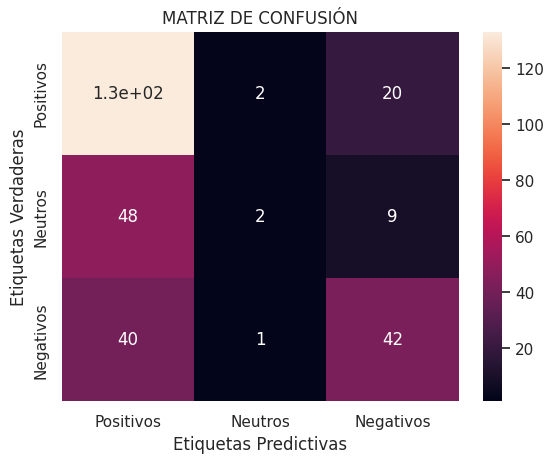

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells

# Etiquetas, Título and medidas
ax.set_xlabel('Etiquetas Predictivas');ax.set_ylabel('Etiquetas Verdaderas');
ax.set_title('MATRIZ DE CONFUSIÓN');
ax.xaxis.set_ticklabels(['Positivos', 'Neutros','Negativos']); ax.yaxis.set_ticklabels(['Positivos', 'Neutros','Negativos']);

# WordCount

In [ ]:
names = ['Id', 'tweet', 'polaridad']
palabras = pd.read_csv('train.txt', sep='\t',names=names)

In [ ]:
palabras['tweet2'] = palabras.tweet.str.strip().str.split('[\W_]+')

<>:1: SyntaxWarning: invalid escape sequence '\W'
<>:1: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipython-input-2069574839.py:1: SyntaxWarning: invalid escape sequence '\W'
  palabras['tweet2'] = palabras.tweet.str.strip().str.split('[\W_]+')


In [ ]:
rows = list()
for row in palabras[['tweet2']].iterrows():
    r = row[1]
    for word in r.tweet2:
        rows.append((word))

tweet2 = pd.DataFrame(rows, columns=['tweet2'])
tweet2.head()

,tweet2
0,No
1,mames
2,este
3,pinche
4,dolor


In [ ]:
tweet2 = tweet2[tweet2.tweet2.str.len() > 0]
tweet2['tweet2'] = tweet2.tweet2.str.lower()
tweet2.head()

,tweet2
0,no
1,mames
2,este
3,pinche
4,dolor


In [ ]:
counts = tweet2\
    .tweet2.value_counts()\
    .to_frame()\
    .rename(columns={'tweet2':'n_w'})
counts.head(15)

,count
tweet2,
que,607
de,581
y,474
no,430
a,371
la,353
me,338
en,257
el,244


In [ ]:
stopwords = stopwords.words('spanish')

In [ ]:
for a_stopword in stopwords:
    if a_stopword in counts.index:
        counts = counts.drop(a_stopword)

In [ ]:
counts.head(20)

,count
tweet2,
si,127
año,63
mejor,50
quiero,50
bien,49
tan,47
días,42
así,40
vida,40


In [ ]:
top_500 = counts.head(500)

In [ ]:
top_20 = counts.head(20)
top_20

,count
tweet2,
si,127
año,63
mejor,50
quiero,50
bien,49
tan,47
días,42
así,40
vida,40


In [ ]:
top_20['palabras'] = counts.head(20)
top_20

/tmp/ipython-input-414253494.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_20['palabras'] = counts.head(20)


,count,palabras
tweet2,,
si,127,127
año,63,63
mejor,50,50
quiero,50,50
bien,49,49
tan,47,47
días,42,42
así,40,40
vida,40,40


     word  n_w
0      si  127
1     año   63
2   mejor   50
3  quiero   50
4    bien   49


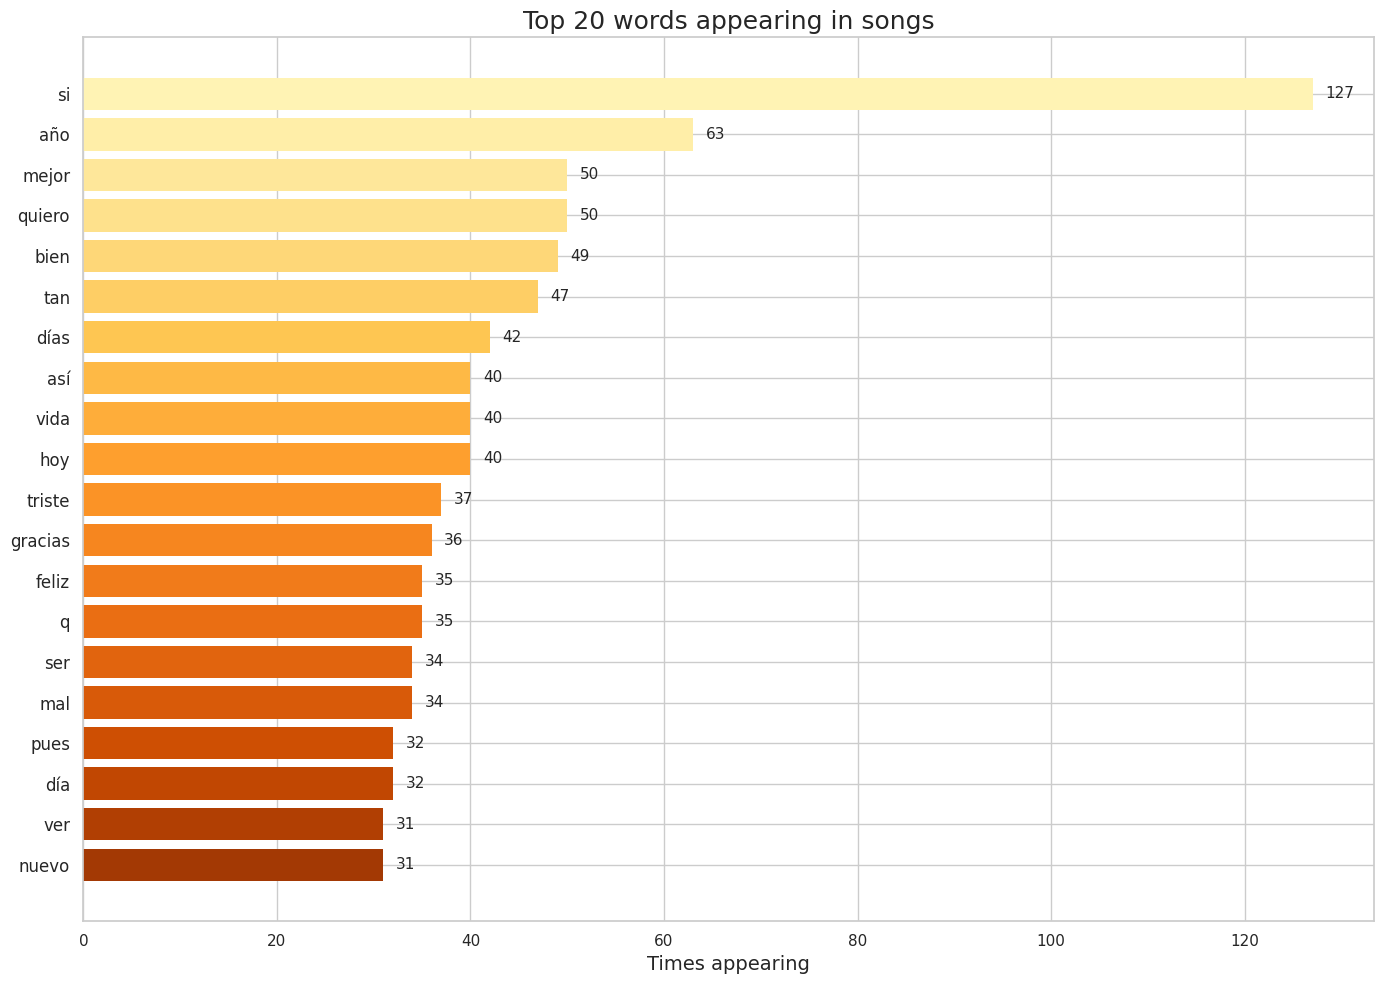

In [ ]:

# --- 2) Preparar top20 correctamente
top20 = counts.head(20).reset_index()         # index -> columna
top20.columns = ['word', 'n_w']               # renombrar columnas
# en caso de que alguna cosa no sea numérica:
top20['n_w'] = top20['n_w'].astype(int)

# Ordenar de menor a mayor para luego invertir el eje y y tener el mayor arriba
top20 = top20.sort_values('n_w', ascending=False).reset_index(drop=True)

# Verifica rápidamente (opcional)
print(top20.head())   # debe mostrar 'word' y 'n_w'

# --- 3) Plot con matplotlib (control total, evita warnings de seaborn)
fig, ax = plt.subplots(figsize=(14,10))

y_positions = np.arange(len(top20))

# paleta usando colormap (evitamos tonos muy claros para que se vean bien)
colors = plt.cm.YlOrBr(np.linspace(0.15, 0.85, len(top20)))

ax.barh(y_positions, top20['n_w'], color=colors, edgecolor='none')

# Etiquetas de palabras en eje Y
ax.set_yticks(y_positions)
ax.set_yticklabels(top20['word'], fontsize=12)

# Poner la palabra más frecuente arriba
ax.invert_yaxis()

# Etiquetas y título
ax.set_xlabel('Times appearing', fontsize=14)
ax.set_title('Top 20 words appearing in songs', fontsize=18)

# Números al final de cada barra
max_n = top20['n_w'].max()
for i, v in enumerate(top20['n_w']):
    ax.text(v + max_n*0.01, i, str(v), va='center', fontsize=11)

plt.tight_layout()
plt.savefig('palabras_populares.jpg', dpi=150)
plt.show()



In [ ]:
top_five_words = counts.head(5).index
top_five_words

Index(['si', 'año', 'mejor', 'quiero', 'bien'], dtype='object', name='tweet2')

In [ ]:
!pip install wordcloud
#conda install -c conda-forge wordcloud

In [ ]:
import re
from PIL import Image
from wordcloud import WordCloud
from collections import Counter

In [ ]:
comment_words = ' '
for val in counts.index:
    # typecaste each val to string
    val = str(val)

    # split the value
    tokens = val.split()

    # Converts each token into lowercase
    for i in range(len(tokens)):
        tokens[i] = tokens[i].lower()

    for words in tokens:
        comment_words = comment_words + words + ' '


In [ ]:
 trump_mask = np.array(Image.open("heart.jpg"))

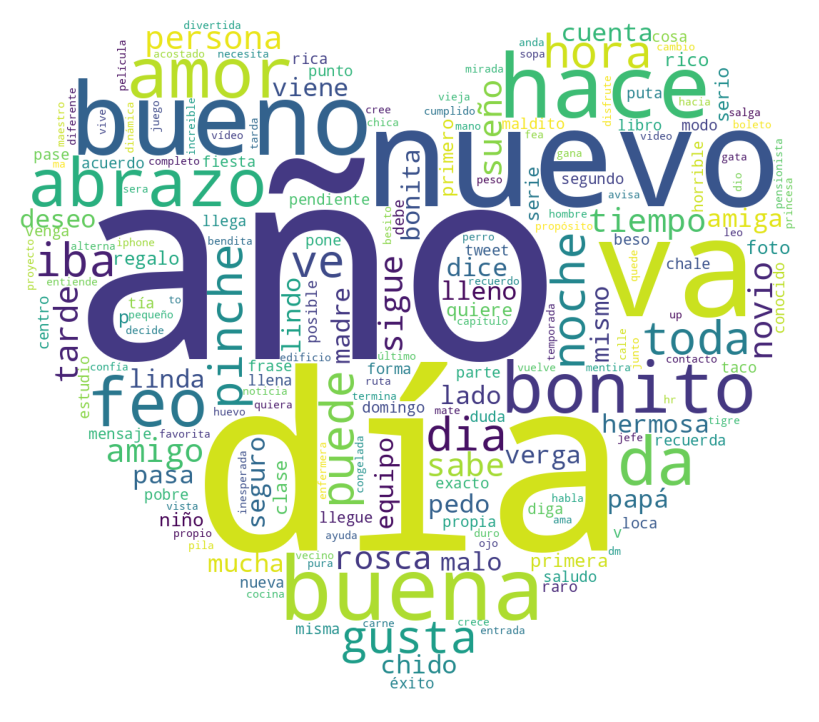

In [ ]:
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = stopwords,
                mask=trump_mask,
                min_font_size = 10).generate(comment_words)
# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

## Conclusión

En esta práctica, analizamos sentimientos de tweets sobre la pandemia. Preparamos los datos (limpieza, tokenización, lematización, stopwords) y los convertimos con TF-IDF. Luego, usamos modelos Naive Bayes y SVM para clasificar los tweets en negativos, neutros o positivos, evaluando su precisión con la matriz de confusión.

También identificamos las palabras más frecuentes y creamos una nube de palabras para entender el contexto. En resumen, aprendimos el ciclo completo del análisis de sentimientos, desde el pre-procesamiento hasta la interpretación de resultados.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>